In [ ]:
import pandas as pd
import cooltools
from ggner_3d.cm import CLR_CONNS, get_eig_data, prepare_view_df, get_expected_cis_df, get_expected_trans_df

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from ggner_3d import plotting
plotting.update_rcparams()
COLORS = plotting.COLORS


SWEIGHT = 'sweight'
RESOLUTION = 100_000
N_GROUPS = 50
Q_LO = 0.025
Q_HI = 0.975
MINDIAG = 2
MAXDIAG = 10_000_000 // RESOLUTION
VIEW_DF = prepare_view_df(arm=False)

clr_ = CLR_CONNS(resolution=RESOLUTION)
compartments_data_EV = {k:get_eig_data(k, resolution=RESOLUTION)[1][['chrom', 'start', 'end', 'E1']] for k in clr_}

def format_sample_name(sample_name):
    return sample_name.replace('WT', 'WT ').replace('XPA', 'XPA ').replace('XPC', 'XPC ')

### ev comparisons (to see if certain chroms are problematic)

In [ ]:
# nan ration in compartments_data_EV['WTnoUV']
df = compartments_data_EV['WTnoUV']
for chrom in df.chrom.unique():
    how_many_nans = df.loc[df.chrom == chrom, 'E1'].isna().sum()
    total_values = df.loc[df.chrom == chrom, 'E1'].shape[0]
    nan_ratio = how_many_nans / total_values
    print(f"Chromosome {chrom}: {nan_ratio:.2%} NaN values in E1")

In [ ]:
plot_data = {}
# perform correlation between samples per chromosome
chroms_oi = []
from scipy.stats import pearsonr
for sample1 in clr_.keys():
    for sample2 in clr_.keys():
        if sample1 >= sample2:
            continue
        corrs = []
        for chrom in VIEW_DF['chrom'].unique():
            ev1 = compartments_data_EV[sample1].loc[compartments_data_EV[sample1]['chrom']==chrom, 'E1']
            ev2 = compartments_data_EV[sample2].loc[compartments_data_EV[sample2]['chrom']==chrom, 'E1']
            # comparte both sides non nan
            valid_idx = (~ev1.isna()) & (~ev2.isna())
            ev1 = ev1[valid_idx]
            ev2 = ev2[valid_idx]
            corr, _ = pearsonr(ev1, ev2)
            corrs.append(corr)
            if corr < 0.5:
                print(f"Low correlation between {sample1} and {sample2} on {chrom}: {corr:.2f}")
                chroms_oi.append(chrom)
        mean_corr = np.mean(corrs)
        plot_data[(sample1, sample2)] = mean_corr

print(set(chroms_oi))

# plot heatmap
heatmap_data = pd.DataFrame(index=clr_.keys(), columns=clr_.keys(), data=np.nan)
for (sample1, sample2), corr in plot_data.items():
    heatmap_data.loc[sample1, sample2] = corr
    heatmap_data.loc[sample2, sample1] = corr

fig, ax = plt.subplots(figsize=(6,5))
vmin = np.nanmin(heatmap_data.values)
# adjust vmin downwards slightly to enhance color contrast
vmin = max(0.5, vmin - 0.05)
sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="vlag", vmin=vmin, vmax=1.0, ax=ax, center=vmin)
ax.set_title("Compartment Score Correlation")
fig.tight_layout()

In [ ]:
from scipy.stats import norm, wasserstein_distance

def normalness_wasserstein(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    
    mu = x.mean()
    sigma = x.std(ddof=1)
    if sigma == 0:
        return np.inf

    # sample from fitted normal with same size
    normal_sample = norm.rvs(loc=mu, scale=sigma, size=len(x))
    
    # Wasserstein distance
    return wasserstein_distance(x, normal_sample)

In [ ]:
compartments_data_EV_full = {k:get_eig_data(k, resolution=RESOLUTION)[1] for k in clr_}

fig, ax = plt.subplots(figsize=(10,6))
ev_labels = ['E1', 'E2', 'E3']

for sample in ['WTnoUV', 'XPAnoUV', 'XPCnoUV']:
    for chrom in clr_[sample].chromnames:
        fig, ax = plt.subplots(1, 3, figsize=(10,6))
        ev_std_mean = {k:[] for k in ev_labels}
        ev_std_mean_gradient = {k:[] for k in ev_labels}
        normalness = {k:[] for k in ev_labels}
        for ev in ev_labels:
            ev_data = compartments_data_EV_full[sample].copy()
            ev_chrom = ev_data.loc[ev_data['chrom']==chrom, ev]
            std, mean = np.nanstd(ev_chrom), np.nanmean(ev_chrom)
            ev_std_mean[ev] = (std, mean)
            sns.lineplot(x=ev_chrom.index, y=ev_chrom, label=f"{ev}-{sample}", ax=ax[0])

            # plot kde of ev values
            sns.kdeplot(ev_chrom.dropna(), label=f"{ev}-{sample}", ax=ax[1])

            # plot np gradient
            gradient = np.gradient(ev_chrom)
            sns.lineplot(x=ev_chrom.index, y=gradient, label=f"{ev}-{sample}", ax=ax[2])
            std_g, mean_g = np.nanstd(gradient), np.nanmean(gradient)
            ev_std_mean_gradient[ev] = (std_g, mean_g)

            # normalness
            normalness[ev] = normalness_wasserstein(ev_chrom)

        ax[1].set_title(f"KDE of Compartment Scores on {chrom} - {sample}")
        ax[1].set_xlabel("Compartment Score")
        ax[1].set_ylabel("Density")
        ax[1].legend()

        # add text
        for ev in ev_labels:
            std, mean = ev_std_mean[ev]
            ax[0].text(0.02, 0.9 - ev_labels.index(ev)*0.05, f"{ev}: mean={mean:.2f}, std={std:.2f}", transform=ax[0].transAxes)
            std_g, mean_g = ev_std_mean_gradient[ev]
            ax[2].text(0.02, 0.9 - ev_labels.index(ev)*0.05, f"{ev} gradient: mean={mean_g:.2f}, std={std_g:.2f}", transform=ax[2].transAxes)
            norm_val = normalness[ev]
            ax[1].text(0.02, 0.7 - ev_labels.index(ev)*0.05, f"{ev} normalness (Wasserstein): {norm_val:.2f}", transform=ax[1].transAxes)   
        ax[0].set_title(f"Compartment Scores on {chrom}")
        ax[0].set_xlabel("Genomic Bin Index (100kb)")
        ax[0].set_ylabel("Compartment Score")
        # add horizontal line at y=0
        ax[0].axhline(0, color='gray', linestyle='--')
        ax[0].legend()

        fig.tight_layout()
        fig.savefig(f"/home/carlos/Clone/ggner-3d/figs/eigenvector_viz/{chrom}_{sample}.png")
        plt.close(fig)

### filter evs by chrom

In [6]:
blacklist = ['chr6', 'chr21', 'chr22']

set()


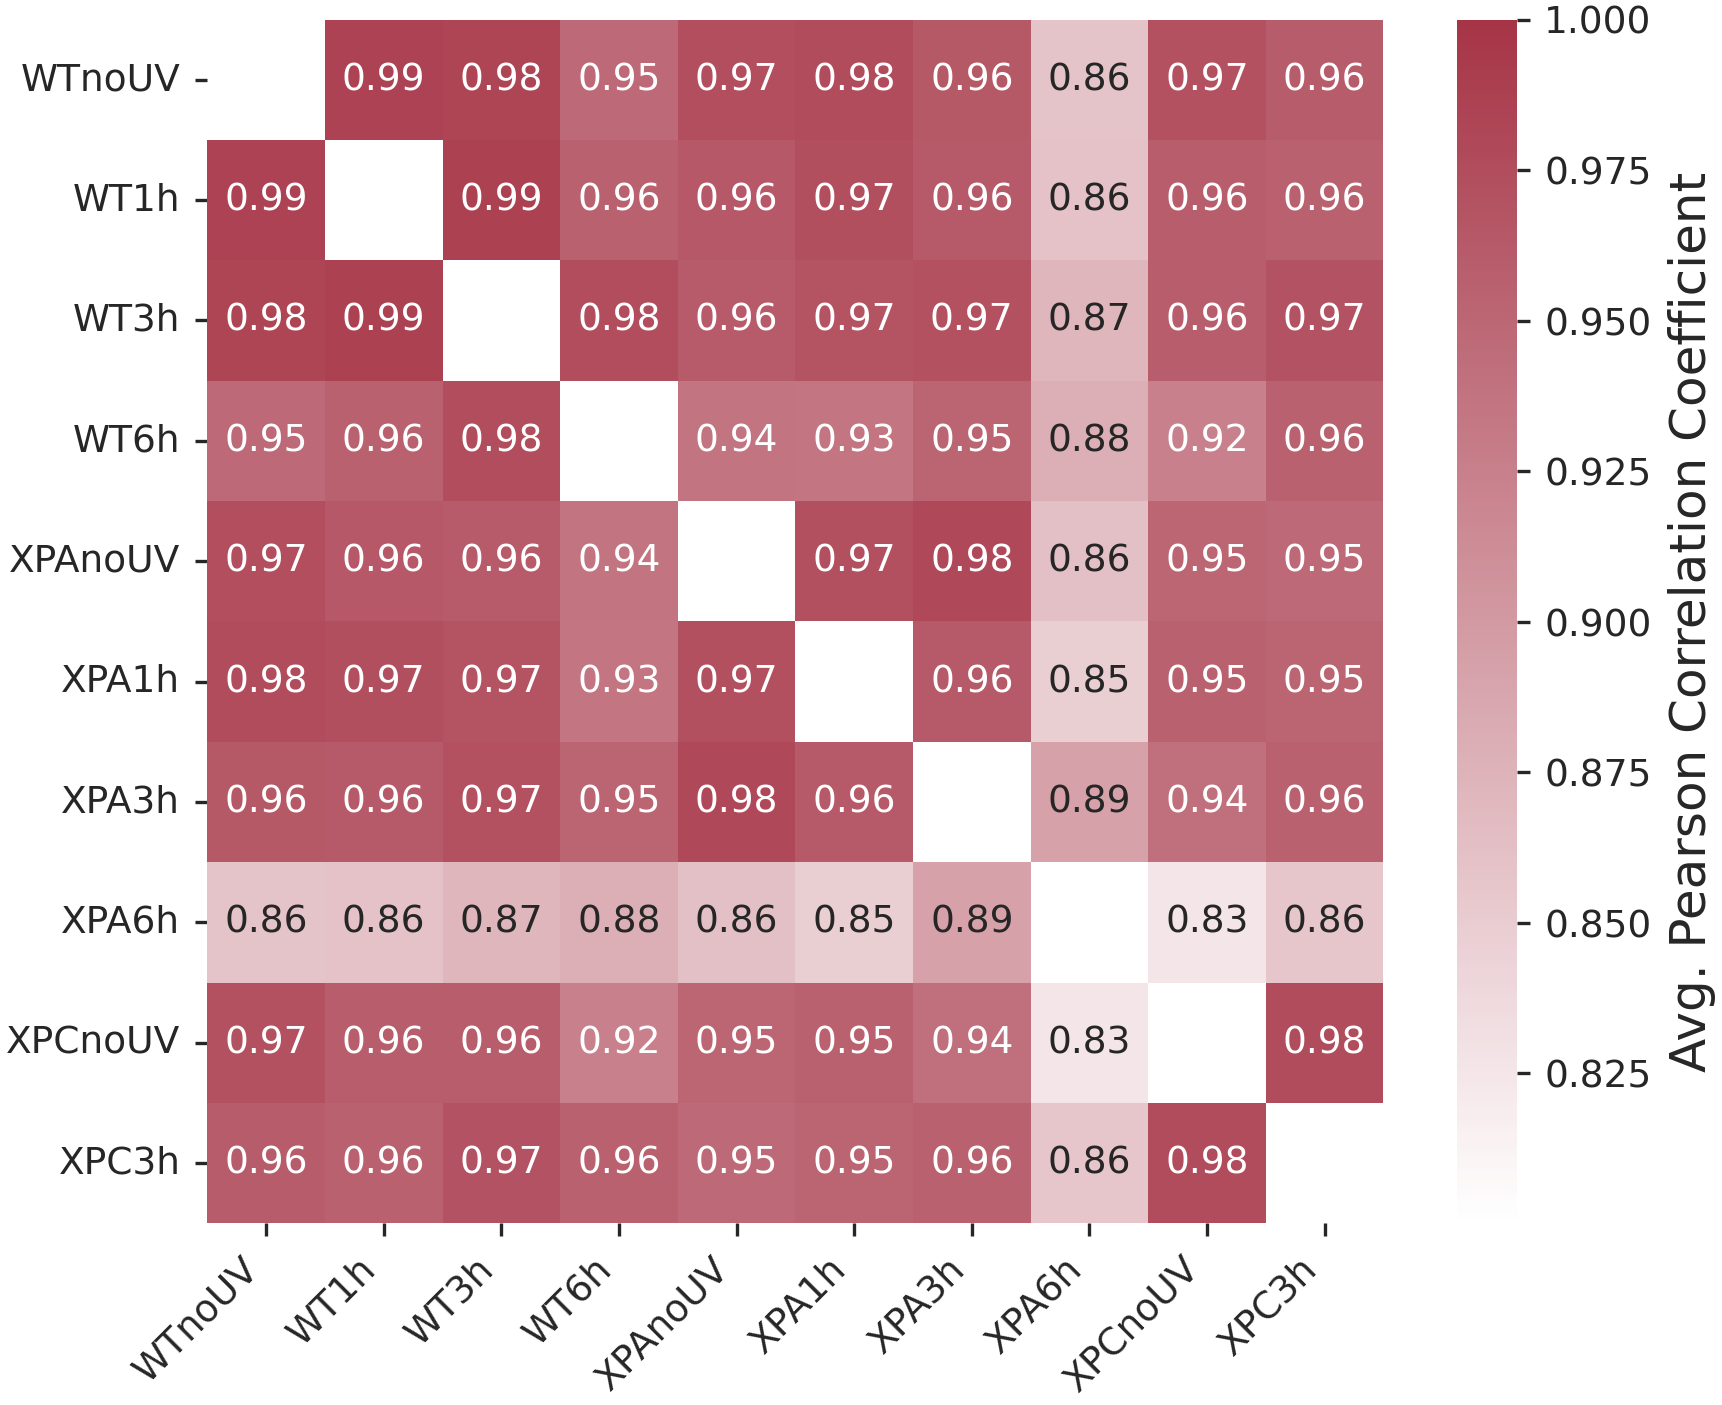

In [7]:
plot_data = {}
# perform correlation between samples per chromosome
chroms_oi = []
from scipy.stats import pearsonr
for sample1 in clr_.keys():
    for sample2 in clr_.keys():
        if sample1 >= sample2:
            continue
        corrs = []
        for chrom in VIEW_DF['chrom'].unique():
            if chrom in blacklist:
                continue
            ev1 = compartments_data_EV[sample1].loc[compartments_data_EV[sample1]['chrom']==chrom, 'E1']
            ev2 = compartments_data_EV[sample2].loc[compartments_data_EV[sample2]['chrom']==chrom, 'E1']
            # comparte both sides non nan
            valid_idx = (~ev1.isna()) & (~ev2.isna())
            ev1 = ev1[valid_idx]
            ev2 = ev2[valid_idx]
            corr, _ = pearsonr(ev1, ev2)
            corrs.append(corr)
            if corr < 0.5:
                print(f"Low correlation between {sample1} and {sample2} on {chrom}: {corr:.2f}")
                chroms_oi.append(chrom)
        mean_corr = np.mean(corrs)
        plot_data[(sample1, sample2)] = mean_corr

print(set(chroms_oi))

# plot heatmap
heatmap_data = pd.DataFrame(index=clr_.keys(), columns=clr_.keys(), data=np.nan)
for (sample1, sample2), corr in plot_data.items():
    heatmap_data.loc[sample1, sample2] = corr
    heatmap_data.loc[sample2, sample1] = corr

fig, ax = plt.subplots(figsize=(6,5))
vmin = np.nanmin(heatmap_data.values)
# adjust vmin downwards slightly to enhance color contrast
vmin = vmin - 0.025

from matplotlib.colors import LinearSegmentedColormap
cmp_heatmap = LinearSegmentedColormap.from_list("custom_cmp", ["white", "#A63446"], N=256)

sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap=cmp_heatmap, vmin=vmin, vmax=1.0, ax=ax, cbar_kws={"label": "Avg. Pearson Correlation Coefficient"})


fig.tight_layout()

# rotate x labels
plt.xticks(rotation=45, ha='right')

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/compartment_correlation_heatmap_filtered.svg")

In [ ]:
def filter_df_by_chrom_blacklist(compartments_data_EV, blacklist):
    filtered_data = {}
    for sample, df in compartments_data_EV.items():
        filtered_df = df[~df['chrom'].isin(blacklist)].reset_index(drop=True)
        filtered_data[sample] = filtered_df
    return filtered_data


compartments_data_EV = filter_df_by_chrom_blacklist(compartments_data_EV, blacklist)

### prepare saddle data

In [ ]:
def saddle_wraper(eigenvector_track, clr, sample_name, conctact_type='cis'):
    if conctact_type == 'cis':
        cvd = get_expected_cis_df(sample_name, resolution_kb=RESOLUTION//1000, label='chrom')
    else:
        cvd = get_expected_trans_df(sample_name, resolution_kb=RESOLUTION//1000)
    return cooltools.saddle(
        clr,
        cvd,
        eigenvector_track,
        contact_type=conctact_type,
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        min_diag=MINDIAG,
        max_diag=MAXDIAG,
        view_df=VIEW_DF,
        clr_weight_name=SWEIGHT,
        trim_outliers=True
    )

In [ ]:
saddle_data_wtnouv = {}
saddle_data_xpcnouv = {}
saddle_data_xpanouv = {}

for current_sample in clr_.keys():
    int_s, int_c = saddle_wraper(compartments_data_EV['WTnoUV'], clr_[current_sample], current_sample)
    saddle_data_wtnouv[current_sample] = (int_s, int_c)

    int_s, int_c = saddle_wraper(compartments_data_EV['XPCnoUV'], clr_[current_sample], current_sample)
    saddle_data_xpcnouv[current_sample] = (int_s, int_c)

    int_s, int_c = saddle_wraper(compartments_data_EV['XPAnoUV'], clr_[current_sample], current_sample)
    saddle_data_xpanouv[current_sample] = (int_s, int_c)

In [ ]:
# trans saddle calculation in parallel

# import time
# from joblib import Parallel, delayed

# def run_one_sample(sample_name):
#     clr = clr_[sample_name]
#     wt  = saddle_wraper(compartments_data_EV['WTnoUV'],  clr, sample_name, conctact_type='trans')
#     xpc = saddle_wraper(compartments_data_EV['XPCnoUV'], clr, sample_name, conctact_type='trans')
#     xpa = saddle_wraper(compartments_data_EV['XPAnoUV'], clr, sample_name, conctact_type='trans')
#     return sample_name, wt, xpc, xpa

# samples = list(clr_.keys())
# n = len(samples)

# t0 = time.time()
# done = 0

# def wrapped(sample_name):
#     # run and return timing too
#     t_start = time.time()
#     out = run_one_sample(sample_name)
#     return out, time.time() - t_start

# results = []
# # batch_size=1 gives you smoother progress/ETA updates (more overhead, but best visibility)
# for (out, dt) in Parallel(
#     n_jobs=6,
#     backend="loky",
#     verbose=10,
#     batch_size=1,
#     return_as="generator",
#     pre_dispatch="2*n_jobs",
# )(delayed(wrapped)(s) for s in samples):
#     results.append(out)

#     done += 1
#     elapsed = time.time() - t0
#     rate = done / elapsed
#     remaining = n - done
#     eta_sec = remaining / rate if rate > 0 else float("inf")

#     print(f"[{done}/{n}] last={dt/60:.1f} min | elapsed={elapsed/60:.1f} min | ETA={eta_sec/60:.1f} min")

# saddle_data_wtnouv_trans  = {s: wt  for s, wt,  xpc, xpa in results}
# saddle_data_xpcnouv_trans = {s: xpc for s, wt,  xpc, xpa in results}
# saddle_data_xpanouv_trans = {s: xpa for s, wt,  xpc, xpa in results}

In [ ]:
base_sample = "WTnoUV"
comparison_samples = [s for s in saddle_data_wtnouv.keys() if s != base_sample and "WT" in s]
print("Comparing samples:", comparison_samples)

# --- compute matrices ---
base_s, base_c = saddle_data_wtnouv[base_sample]
base_mtx = base_s / base_c

diff_data = []
for comp_sample in comparison_samples:
    print("Processing comparison sample:", comp_sample)
    comp_s, comp_c = saddle_data_wtnouv[comp_sample]
    comp_mtx = comp_s / comp_c
    diff_data.append(comp_mtx - base_mtx)

vmin, vmax = np.min(diff_data), np.max(diff_data)

# --- layout: ax0=base, ax1=base cbar, ax2..=diff heatmaps, last ax=shared diff cbar ---
n_comp = len(comparison_samples)
ncols = 2 + n_comp + 1  # base + base_cbar + diffs + diff_cbar

fig = plt.figure(figsize=(5 * (n_comp + 2), 4))
# make cbar columns skinny
width_ratios = [1.0, 0.06] + [1.0] * n_comp + [0.06]
gs = fig.add_gridspec(1, ncols, width_ratios=width_ratios, wspace=0.05)

axs = [fig.add_subplot(gs[0, i]) for i in range(ncols)]
ax_base = axs[0]
ax_base_cbar = axs[1]
ax_diff_list = axs[2:2 + n_comp]
ax_diff_cbar = axs[-1]

# --- base heatmap ---
sns.heatmap(
    base_mtx,
    ax=ax_base,
    cmap="vlag",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    center=1
)
ax_base.set_title(f"{format_sample_name(base_sample)}")
ax_base.margins(0)

# base colorbar in ax1
import matplotlib as mpl

norm_base = mpl.colors.Normalize(vmin=np.min(base_mtx), vmax=np.max(base_mtx))
sm_base = mpl.cm.ScalarMappable(cmap="vlag", norm=norm_base)
sm_base.set_array([])
fig.colorbar(sm_base, cax=ax_base_cbar, label="Avg. Obs/Exp")

# --- diff heatmaps ---
for ax, comp_sample, diff_mtx in zip(ax_diff_list, comparison_samples, diff_data):
    sns.heatmap(
        diff_mtx,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        center=0,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )
    ax.set_title(f"{format_sample_name(comp_sample)} - {format_sample_name(base_sample)}")
    ax.margins(0)

# shared diff colorbar in last axis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="vlag", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=ax_diff_cbar, label="Δ Saddle Matrix")

fig.tight_layout()  

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/compartment_saddle_differences_wtnouv_vs_wt.svg")

In [ ]:
import importlib
importlib.reload(plotting)
plotting.update_rcparams()
grid = plotting.saddleplot(
    compartments_data_EV['WTnoUV'],
    saddle_data_wtnouv['WTnoUV'][0]/saddle_data_wtnouv['WTnoUV'][1],
    N_GROUPS,
    qrange=(Q_LO, Q_HI),
    cmap='vlag',
    color='gray',
    clabel='Avg. Obs/Exp Contact Frequency',
)

fig = grid["ax_heatmap"].figure
fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/compartment_saddle_wtnouv.svg", bbox_inches="tight")

In [ ]:
def filter_saddle_data(saddle_data, samples):
    if samples is None:
        return saddle_data
    filtered_data = {}
    for sample in samples:
        filtered_data[sample] = saddle_data[sample]
    return filtered_data

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
samples_of_interest = [s for s in saddle_data_wtnouv.keys() if 'WT' in s]

p, _ = plotting.plot_saddle_strength_profiles(
    filter_saddle_data(saddle_data_wtnouv, samples_of_interest), ax=ax, n_groups=N_GROUPS-2, title='', xlabel='Group Extent', line_kws={'linewidth':1.2},
)
plotting.despine(ax)
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/saddle_strength_profiles_wt.svg')

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(6, 6), sharex=True)
samples_of_interest = ['WTnoUV', 'XPCnoUV', 'XPAnoUV']
p1, _ = plotting.plot_saddle_strength_profiles(
    filter_saddle_data(saddle_data_wtnouv, samples_of_interest), ax=ax[0], n_groups=N_GROUPS-2, title='', xlabel='Group Extent', line_kws={'linewidth':1.0}, ylabel='Comp. Strength'
)
plotting.despine(p1)

samples_of_interest = ['XPCnoUV', 'XPC3h']
p2, _ = plotting.plot_saddle_strength_profiles(
    filter_saddle_data(saddle_data_xpcnouv, samples_of_interest), ax=ax[1], n_groups=N_GROUPS-2, title='', xlabel='Group Extent', line_kws={'linewidth':1.0}, ylabel='Comp. Strength'
)
plotting.despine(p2)

samples_of_interest = ['XPAnoUV', 'XPA1h', 'XPA3h', 'XPA6h']
p3, _ = plotting.plot_saddle_strength_profiles(
    filter_saddle_data(saddle_data_xpanouv, samples_of_interest), ax=ax[2], n_groups=N_GROUPS-2, title='', xlabel='Group Extent', line_kws={'linewidth':1.0}, ylabel='Comp. Strength'
)
plotting.despine(p3)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/saddle_strength_profiles_cell_type_comparison.svg')

In [ ]:
base_sample = "WTnoUV"
comparison_samples = ['XPAnoUV', 'XPCnoUV']
print("Comparing samples:", comparison_samples)

# --- compute matrices ---
base_s, base_c = saddle_data_wtnouv[base_sample]
base_mtx = base_s / base_c

diff_data = []
for comp_sample in comparison_samples:
    print("Processing comparison sample:", comp_sample)
    comp_s, comp_c = saddle_data_wtnouv[comp_sample]
    comp_mtx = comp_s / comp_c
    diff_data.append(comp_mtx - base_mtx)

vmin, vmax = np.min(diff_data), np.max(diff_data)

# --- layout: ax0=base, ax1=base cbar, ax2..=diff heatmaps, last ax=shared diff cbar ---
n_comp = len(comparison_samples)
ncols = 2 + n_comp + 1  # base + base_cbar + diffs + diff_cbar

fig = plt.figure(figsize=(5 * (n_comp + 2), 4))
# make cbar columns skinny
width_ratios = [1.0, 0.06] + [1.0] * n_comp + [0.06]
gs = fig.add_gridspec(1, ncols, width_ratios=width_ratios, wspace=0.05)

axs = [fig.add_subplot(gs[0, i]) for i in range(ncols)]
ax_base = axs[0]
ax_base_cbar = axs[1]
ax_diff_list = axs[2:2 + n_comp]
ax_diff_cbar = axs[-1]

# --- base heatmap ---
sns.heatmap(
    base_mtx,
    ax=ax_base,
    cmap="vlag",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    center=1
)
ax_base.set_title(f"{format_sample_name(base_sample)}")
ax_base.margins(0)

# base colorbar in ax1
import matplotlib as mpl

norm_base = mpl.colors.Normalize(vmin=np.min(base_mtx), vmax=np.max(base_mtx))
sm_base = mpl.cm.ScalarMappable(cmap="vlag", norm=norm_base)
sm_base.set_array([])
fig.colorbar(sm_base, cax=ax_base_cbar, label="Avg. Obs/Exp")

# --- diff heatmaps ---
for ax, comp_sample, diff_mtx in zip(ax_diff_list, comparison_samples, diff_data):
    sns.heatmap(
        diff_mtx,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        center=0,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )
    ax.set_title(f"{format_sample_name(comp_sample)} - {format_sample_name(base_sample)}")
    ax.margins(0)

# shared diff colorbar in last axis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="vlag", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=ax_diff_cbar, label="Δ Saddle Matrix")

fig.tight_layout()  

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/compartment_saddle_differences_wtnouv_cell_types.svg")

In [ ]:
base_sample = "XPAnoUV"
comparison_samples = ['XPA1h', 'XPA3h', 'XPA6h']
print("Comparing samples:", comparison_samples)

# --- compute matrices ---
base_s, base_c = saddle_data_wtnouv[base_sample]
base_mtx = base_s / base_c

diff_data = []
for comp_sample in comparison_samples:
    print("Processing comparison sample:", comp_sample)
    comp_s, comp_c = saddle_data_wtnouv[comp_sample]
    comp_mtx = comp_s / comp_c
    diff_data.append(comp_mtx - base_mtx)

vmin, vmax = np.min(diff_data), np.max(diff_data)

# --- layout: ax0=base, ax1=base cbar, ax2..=diff heatmaps, last ax=shared diff cbar ---
n_comp = len(comparison_samples)
ncols = 2 + n_comp + 1  # base + base_cbar + diffs + diff_cbar

fig = plt.figure(figsize=(5 * (n_comp + 2), 4))
# make cbar columns skinny
width_ratios = [1.0, 0.06] + [1.0] * n_comp + [0.06]
gs = fig.add_gridspec(1, ncols, width_ratios=width_ratios, wspace=0.05)

axs = [fig.add_subplot(gs[0, i]) for i in range(ncols)]
ax_base = axs[0]
ax_base_cbar = axs[1]
ax_diff_list = axs[2:2 + n_comp]
ax_diff_cbar = axs[-1]

# --- base heatmap ---
sns.heatmap(
    base_mtx,
    ax=ax_base,
    cmap="vlag",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    center=1
)
ax_base.set_title(f"{format_sample_name(base_sample)}")
ax_base.margins(0)

# base colorbar in ax1
import matplotlib as mpl

norm_base = mpl.colors.Normalize(vmin=np.min(base_mtx), vmax=np.max(base_mtx))
sm_base = mpl.cm.ScalarMappable(cmap="vlag", norm=norm_base)
sm_base.set_array([])
fig.colorbar(sm_base, cax=ax_base_cbar, label="Avg. Obs/Exp")

# --- diff heatmaps ---
for ax, comp_sample, diff_mtx in zip(ax_diff_list, comparison_samples, diff_data):
    sns.heatmap(
        diff_mtx,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        center=0,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )
    ax.set_title(f"{format_sample_name(comp_sample)} - {format_sample_name(base_sample)}")
    ax.margins(0)

# shared diff colorbar in last axis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="vlag", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=ax_diff_cbar, label="Δ Saddle Matrix")

fig.tight_layout()  

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/compartment_saddle_differences_wtnouv_xpa.svg")

In [ ]:
base_sample = "XPCnoUV"
comparison_samples = ['XPC3h']
print("Comparing samples:", comparison_samples)

# --- compute matrices ---
base_s, base_c = saddle_data_wtnouv[base_sample]
base_mtx = base_s / base_c

diff_data = []
for comp_sample in comparison_samples:
    print("Processing comparison sample:", comp_sample)
    comp_s, comp_c = saddle_data_wtnouv[comp_sample]
    comp_mtx = comp_s / comp_c
    diff_data.append(comp_mtx - base_mtx)

vmin, vmax = np.min(diff_data), np.max(diff_data)

# --- layout: ax0=base, ax1=base cbar, ax2..=diff heatmaps, last ax=shared diff cbar ---
n_comp = len(comparison_samples)
ncols = 2 + n_comp + 1  # base + base_cbar + diffs + diff_cbar

fig = plt.figure(figsize=(5 * (n_comp + 2), 4))
# make cbar columns skinny
width_ratios = [1.0, 0.06] + [1.0] * n_comp + [0.06]
gs = fig.add_gridspec(1, ncols, width_ratios=width_ratios, wspace=0.05)

axs = [fig.add_subplot(gs[0, i]) for i in range(ncols)]
ax_base = axs[0]
ax_base_cbar = axs[1]
ax_diff_list = axs[2:2 + n_comp]
ax_diff_cbar = axs[-1]

# --- base heatmap ---
sns.heatmap(
    base_mtx,
    ax=ax_base,
    cmap="vlag",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    center=1
)
ax_base.set_title(f"{format_sample_name(base_sample)}")
ax_base.margins(0)

# base colorbar in ax1
import matplotlib as mpl

norm_base = mpl.colors.Normalize(vmin=np.min(base_mtx), vmax=np.max(base_mtx))
sm_base = mpl.cm.ScalarMappable(cmap="vlag", norm=norm_base)
sm_base.set_array([])
fig.colorbar(sm_base, cax=ax_base_cbar, label="Avg. Obs/Exp")

# --- diff heatmaps ---
for ax, comp_sample, diff_mtx in zip(ax_diff_list, comparison_samples, diff_data):
    sns.heatmap(
        diff_mtx,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        center=0,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )
    ax.set_title(f"{format_sample_name(comp_sample)} - {format_sample_name(base_sample)}")
    ax.margins(0)

# shared diff colorbar in last axis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="vlag", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=ax_diff_cbar, label="Δ Saddle Matrix")

fig.tight_layout()  

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/compartment_saddle_differences_wtnouv_xpc.svg")